In [1]:
import torch
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from safetensors.torch import load_file
import json

In [5]:
import torch
import sys
import subprocess

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Torch CUDA runtime tag:", torch.version.cuda)
print("torch.cuda.is_available():", torch.cuda.is_available())

try:
    out = subprocess.check_output(["nvidia-smi", "-L"], text=True)
    print("nvidia-smi detected GPUs:")
    print(out)
except Exception as e:
    print("nvidia-smi check failed:", e)

Python: 3.13.15 | packaged by conda-forge | (main, Aug 10 2026, 13:05:01) [GCC 14.4.0]
Torch: 2.6.0+cu124
Torch CUDA runtime tag: 12.4
torch.cuda.is_available(): True
nvidia-smi detected GPUs:
GPU 0: NVIDIA L4 (UUID: GPU-9774d39d-3704-9391-3d24-c14e1d8dd9b0)



In [3]:
device = torch.device('cuda')

In [4]:
tensors = load_file("/workspace/results/patient_graphs.safetensors")["patient_graphs"].to(device)

In [6]:
with open("/workspace/results/patient_graphs_meta.json", "r") as f:
    sample_ids = json.load(f)["sample_ids"]

In [8]:
pheno_df = pd.read_parquet("/workspace/data/GSE111629_pheno_data.parquet")

In [9]:
if pheno_df.index.name != "Sample_Name":
    pheno_df = pheno_df.set_index("Sample_Name")
pheno_aligned = pheno_df.loc[sample_ids]

In [14]:
y = torch.tensor(pd.get_dummies(pheno_aligned['Sample_Group']).values.astype(np.float32), device=device)
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
u = torch.tensor(pheno_aligned[cell_cols].values.astype(np.float32), device=device)

In [18]:
y_label = torch.argmax(y, dim=1)  # collapse one-hot back to a single 0/1 label for sklearn/XGBoost
y_cpu = y_label.cpu().numpy()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
roc_aucs = []
pr_aucs = []

In [20]:
for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y_cpu)), y_cpu)):
    
    # --- A. Isolate Fold Data (On GPU) ---
    X_train, X_test = tensors[train_idx], tensors[test_idx]
    y_train, y_test = y_label[train_idx], y_label[test_idx]
    u_train, u_test = u[train_idx], u[test_idx]
    
    # --- B. GPU Unsupervised Feature Selection ---
    # Calculated instantly on CUDA cores
    train_variances = X_train[:, :, 0].var(dim=0) 
    top_5k_indices = torch.topk(train_variances, 5000).indices
    
    # --- C. Slice and Flatten Tensors ---
    X_train_sub = X_train[:, top_5k_indices, :]
    X_test_sub = X_test[:, top_5k_indices, :]
    
    X_train_flat = X_train_sub.reshape(X_train_sub.shape[0], -1)
    X_test_flat = X_test_sub.reshape(X_test_sub.shape[0], -1)
    
    # --- D. Modality Integration ---
    X_train_final = torch.cat([X_train_flat, u_train], dim=1)
    X_test_final = torch.cat([X_test_flat, u_test], dim=1)
    
    # --- E. Handle Class Imbalance ---
    neg_count = (y_train == 0).sum().item()
    pos_count = (y_train == 1).sum().item()
    scale_weight = neg_count / pos_count
    
    # --- F. Train XGBoost Natively on GPU ---
    clf = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        scale_pos_weight=scale_weight,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist', # Enables modern XGBoost histogram algorithm
        device='cuda'       # Executes directly on your NVIDIA GPU
    )
    
    # XGBoost accepts PyTorch CUDA tensors natively!
    clf.fit(X_train_final, y_train)
    
    # --- G. Evaluate ---
    y_pred_proba = clf.predict_proba(X_test_final)[:, 1]
    
    # Scikit-learn metrics require CPU numpy arrays
    fold_roc = roc_auc_score(y_test.cpu().numpy(), y_pred_proba)
    fold_pr = average_precision_score(y_test.cpu().numpy(), y_pred_proba)
    
    roc_aucs.append(fold_roc)
    pr_aucs.append(fold_pr)
    
    print(f"Fold {fold+1} | ROC AUC: {fold_roc:.4f} | PR AUC: {fold_pr:.4f}")

Fold 1 | ROC AUC: 0.6546 | PR AUC: 0.6933
Fold 2 | ROC AUC: 0.5599 | PR AUC: 0.6502
Fold 3 | ROC AUC: 0.6860 | PR AUC: 0.7279
Fold 4 | ROC AUC: 0.6436 | PR AUC: 0.6909
Fold 5 | ROC AUC: 0.7131 | PR AUC: 0.7735


In [21]:
print("-" * 30)
print(f"Mean ROC AUC: {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")
print(f"Mean PR AUC:  {np.mean(pr_aucs):.4f} ± {np.std(pr_aucs):.4f}")

------------------------------
Mean ROC AUC: 0.6515 ± 0.0519
Mean PR AUC:  0.7072 ± 0.0413


In [23]:
%conda install shap -y

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.5.3
    latest version: 26.7.1

Please update conda by running

    $ conda self update



## Package Plan ##

  environment location: /opt/conda/envs/rapids-env

  added / updated specs:
    - shap


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    shap-0.51.0                |cpu_py313h80a60be_1         3.8 MB
    slicer-0.0.8               |  py313h77c3f3f_2          44 KB
    ------------------------------------------------------------
                                           Total:         3.9 MB

The following NEW packages will be INSTALLED:

  shap               pkgs/main/linux-64::shap-0.51.0-cpu_py313h80a60be_1 
  slicer             pkgs/main/linux-64::slicer-0.0.8-py313h77c3f3f

/opt/conda/envs/rapids-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 1000x800 with 0 Axes>

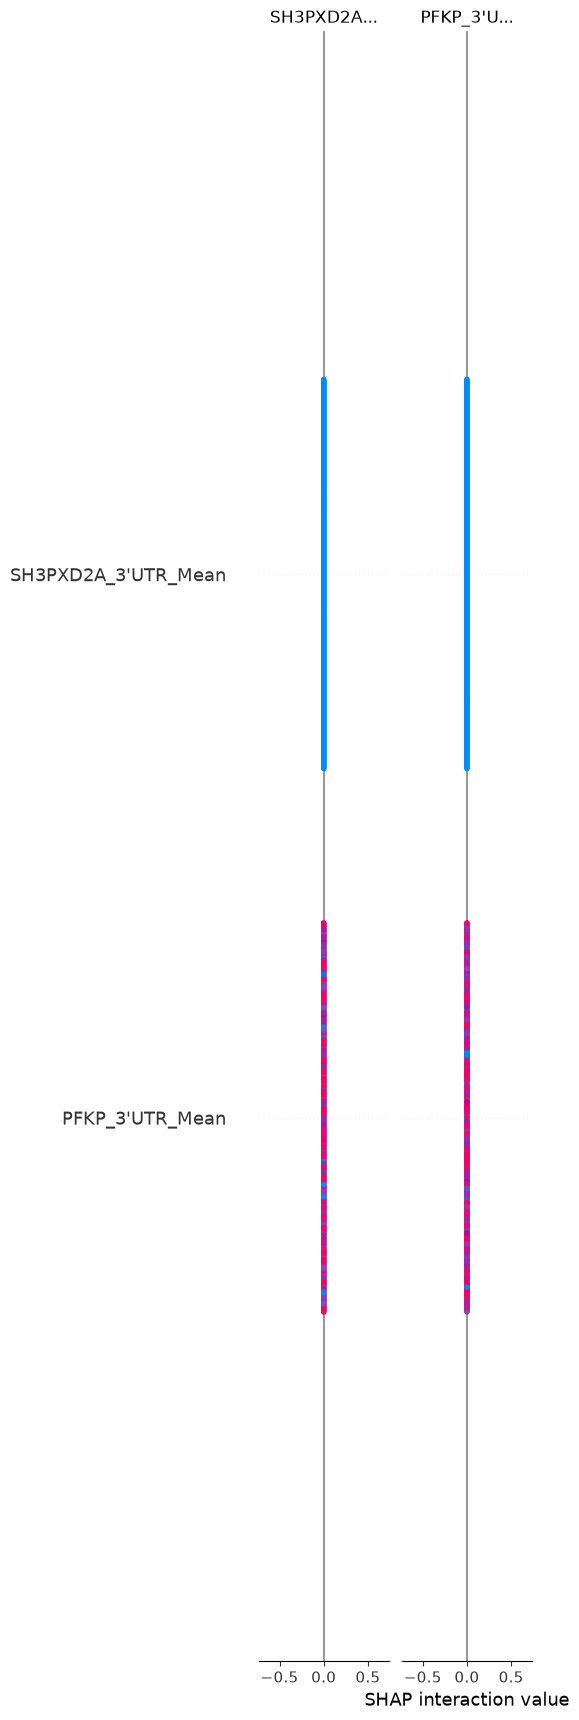

In [ ]:
import shap
import json
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Map the 5,000 top indices back to string names
with open("/workspace/results/patient_graphs_meta.json", "r") as f:
    ordered_regions = json.load(f)["ordered_regions"]

# Recalculate top 5k on the full dataset to match the global model
global_variances = tensors[:, :, 0].var(dim=0)
top_5k_indices = torch.topk(global_variances, 5000).indices

# Generate the 10,006 feature names
hvg_names = [ordered_regions[i.item()] for i in top_5k_indices]
feature_names = (
    [f"{name}_Mean" for name in hvg_names] + 
    [f"{name}_Var" for name in hvg_names] + 
    ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
)

# 2. Prepare the Global Matrix
X_sub = tensors[:, top_5k_indices, :]
X_flat = X_sub.reshape(X_sub.shape[0], -1)
# SHAP requires CPU numpy arrays for visualization
X_final = torch.cat([X_flat, u], dim=1).cpu().numpy() 
y_final = y.cpu().numpy()

# 3. Train the Global Explainer Model
clf = xgb.XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05, 
    scale_pos_weight=scale_weight, eval_metric='logloss',
    random_state=42, tree_method='hist', device='cuda'
)
clf.fit(X_final, y_final)

# 1. Initialize the Explainer
explainer = shap.TreeExplainer(clf)
raw_shap_values = explainer.shap_values(X_final)

# 2. Intercept and format the SHAP output
# If SHAP returns a list [Controls_Array, PD_Array], grab the PD array
if isinstance(raw_shap_values, list):
    shap_values_2d = raw_shap_values[1]
# If SHAP returns a 3D array (samples, features, classes), slice the PD class
elif len(raw_shap_values.shape) == 3:
    shap_values_2d = raw_shap_values[:, :, 1]
# Otherwise, it's already a standard 2D array
else:
    shap_values_2d = raw_shap_values

# 3. Generate the correct Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_2d, 
    X_final, 
    feature_names=feature_names, 
    max_display=20,
    plot_type="dot"  # Explicitly forces the beeswarm layout
)
plt.show()